# BrainScanML

Karlo Nahro — 6G6Z0019 Synoptic Project, July 2025

I compared three transfer-learning models for four-class brain MRI classification and averaged their predictions. Saved results: 97.56% accuracy and 97.49% macro-F1 on 859 test images.

This portfolio copy restores the submitted notebook and updates its explanations. Saved outputs are historical, not a fresh run. The code uses original Colab paths. See README.md for the maintained local scripts and SUBMISSION_NOTES.md for corrections.


## Project aim

Compare Xception, VGG16 and EfficientNetB0, combine their predictions, and inspect errors and confidence. This is a student image-classification project, not a clinically validated diagnostic system.


## Scope

The results describe one image-level split. Patient independence, external generalisation and clinical benefit have not been established.


In [ ]:
# ---- Mount Drive ----
from google.colab import drive
drive.mount('/content/drive')

# ---- Imports ----
import pathlib, textwrap, yaml, pprint, os, shutil
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit
from pathlib import Path

# ---- Paths ----
PROJECT_ROOT = pathlib.Path("/content/drive/MyDrive/Final_2025_Comp/SP")
SRC_DIR   = PROJECT_ROOT / "src"
RAW_DIR   = PROJECT_ROOT / "dataset_brain"          # existing: glioma/meningioma/notumor/pituitary
SPLIT_DIR = PROJECT_ROOT / "dataset_brain_split"    # we'll create this
MODEL_DIR = PROJECT_ROOT / "models"
PLOT_DIR  = PROJECT_ROOT / "plots"
LOG_DIR   = MODEL_DIR / "logs"
SPLITS_CSV = PROJECT_ROOT / "splits.csv"

for p in [SRC_DIR, MODEL_DIR, PLOT_DIR, LOG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

## Data split

The saved manifest contains 5,349 training, 945 validation and 859 test images. Stratification preserves class proportions; it does not establish patient separation. The next cell creates the split only if the manifest is absent.


In [20]:
# ---(RUN ONCE) ----

# ---- Create a stratified train/val/test split
if not SPLITS_CSV.exists():
    # 1) Detect classes automatically
    class_dirs = [p for p in RAW_DIR.iterdir() if p.is_dir()]
    if not class_dirs:
        raise RuntimeError(f"No class folders found under {RAW_DIR}")
    labels = [d.name for d in class_dirs]
    print("Detected classes:", labels)

    # 2) Index images (handle mixed extensions)
    exts = {".jpg", ".jpeg", ".png", ".JPG", ".PNG"}
    rows = []
    for d in class_dirs:
        for img in d.glob("*"):
            if img.suffix in exts:
                rows.append({"path": str(img), "label": d.name})
    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError("No images found. Check extensions or RAW_DIR.")
    print("Per-class counts:", df.label.value_counts().to_dict())

    # 3) Stratified splits
    sss_test = StratifiedShuffleSplit(test_size=0.12, random_state=2025)
    trainval_idx, test_idx = next(sss_test.split(df["path"], df["label"]))
    df["split"] = "trainval"
    df.loc[test_idx, "split"] = "test"

    tv = df.query("split=='trainval'")
    sss_val = StratifiedShuffleSplit(test_size=0.15, random_state=2025)
    tr_i, va_i = next(sss_val.split(tv["path"], tv["label"]))
    df.loc[tv.index[tr_i], "split"] = "train"
    df.loc[tv.index[va_i], "split"] = "val"

    # 4) Save CSV
    df.to_csv(SPLITS_CSV, index=False)
    print("✓ Wrote", SPLITS_CSV)
    print(df.split.value_counts())

    # 5) Copy files to directory tree so your loader still works
    SPLIT_DIR.mkdir(parents=True, exist_ok=True)
    for split in ["train", "val", "test"]:
        for lab in labels:
            (SPLIT_DIR / split / lab).mkdir(parents=True, exist_ok=True)

    for _, r in df.iterrows():
        src = Path(r.path)
        dst = SPLIT_DIR / r.split / r.label / src.name
        if not dst.exists():
            shutil.copy(src, dst)

    print("✓ Copied files to", SPLIT_DIR)
else:
    print("Split already exists – skipping creation. Delete splits.csv to regenerate.")
    df = pd.read_csv(SPLITS_CSV)

# ---- Point DATA_DIR at the split ----
DATA_DIR = SPLIT_DIR

# ---- Write config.yaml ----
yaml_text = textwrap.dedent(f"""
    # ---------- General ----------
    seed: 42
    img_size: [224, 224]
    batch_size: 32
    val_split: 0.15   # kept for compatibility; ignored because val dir exists
    class_mode: categorical

    # ---------- Directories ----------
    data_dir: {DATA_DIR.as_posix()}
    model_dir: {MODEL_DIR.as_posix()}
    log_dir: {LOG_DIR.as_posix()}
    plot_dir: {PLOT_DIR.as_posix()}

    # ---------- Training ----------
    epochs_head: 15
    epochs_finetune: 20
    unfreeze_layers: 30
    lr_head: 1.0e-3
    lr_finetune: 1.0e-4
    early_stop_patience: 4

    # ---------- Ensemble ----------
    backbones: [xception, vgg16, efficientnetb0]
""").lstrip()

cfg_path = SRC_DIR / "config.yaml"
cfg_path.write_text(yaml_text)
print("✓ Wrote", cfg_path)

# ---- Show config to confirm ----
cfg = yaml.safe_load(cfg_path.read_text())
pprint.pprint(cfg, compact=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Detected classes: ['pituitary', 'notumor', 'meningioma', 'glioma']
Per-class counts: {'notumor': 2000, 'meningioma': 1775, 'pituitary': 1757, 'glioma': 1621}
✓ Wrote /content/drive/MyDrive/Final_2025_Comp/SP/splits.csv
split
train    5349
val       945
test      859
Name: count, dtype: int64
✓ Copied files to /content/drive/MyDrive/Final_2025_Comp/SP/dataset_brain_split
✓ Wrote /content/drive/MyDrive/Final_2025_Comp/SP/src/config.yaml
{'backbones': ['xception', 'vgg16', 'efficientnetb0'],
 'batch_size': 32,
 'class_mode': 'categorical',
 'data_dir': '/content/drive/MyDrive/Final_2025_Comp/SP/dataset_brain_split',
 'early_stop_patience': 4,
 'epochs_finetune': 20,
 'epochs_head': 15,
 'img_size': [224, 224],
 'log_dir': '/content/drive/MyDrive/Final_2025_Comp/SP/models/logs',
 'lr_finetune': 0.0001,
 'lr_head': 0.001,
 'model_dir': '/content/drive/MyDrive/Fina

In [21]:
import pandas as pd, pathlib
PROJECT_ROOT = pathlib.Path("/content/drive/MyDrive/Final_2025_Comp/SP")
df = pd.read_csv(PROJECT_ROOT / "splits.csv")
print(df.groupby(["split","label"]).size())

split  label     
test   glioma         195
       meningioma     213
       notumor        240
       pituitary      211
train  glioma        1212
       meningioma    1327
       notumor       1496
       pituitary     1314
val    glioma         214
       meningioma     235
       notumor        264
       pituitary      232
dtype: int64


## Methods

The models use resized images and backbone-specific preprocessing. Training and validation are separate from the explicit test directory. The original notebook requires its Colab environment and source modules.


In [ ]:
%%writefile /content/drive/MyDrive/Final_2025_Comp/SP/src/utils.py
import os, random, numpy as np, tensorflow as tf

def set_global_determinism(seed: int = 42) -> None:
    """
    Fixes randomness for Python, NumPy and TensorFlow, and requests
    deterministic GPU/CPU ops where possible.
    """
    os.environ["TF_DETERMINISTIC_OPS"] = "1"   # TF 2.12+ flag
    os.environ["PYTHONHASHSEED"]       = str(seed)

    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)

    # Extra belt-and-braces: make cuDNN/eigen choose deterministic paths
    tf.config.experimental.enable_op_determinism()
    # NB: some ops are still nondeterministic

print("✓ utils.py written.")

# -------- smoke-test --------
if __name__ == "__main__":
    set_global_determinism(42)
    import tensorflow as tf, numpy as np
    print("Random sanity check:")
    print("  python  :", random.random())
    print("  numpy   :", np.random.rand())
    print("  tf rand :", tf.random.uniform((1,)).numpy()[0])

Overwriting /content/drive/MyDrive/Final_2025_Comp/SP/src/utils.py


## Data loading

The submitted loader is shown below. Its validation-as-test fallback is a historical limitation; the maintained repository loader requires separate train, validation and test folders.


In [22]:
%%writefile /content/drive/MyDrive/Final_2025_Comp/SP/src/datamodule.py
from pathlib import Path
from dataclasses import dataclass
import yaml, tensorflow as tf

@dataclass
class DataModule:
    cfg_path: str

    def __post_init__(self):
        with open(self.cfg_path) as f:
            self.cfg = yaml.safe_load(f)
        self._build()

    def _build(self):
        p          = Path(self.cfg["data_dir"])
        img_size   = tuple(self.cfg["img_size"])
        bs         = self.cfg["batch_size"]
        seed       = self.cfg["seed"]
        val_split  = self.cfg["val_split"]
        class_mode = self.cfg["class_mode"]

        self.train_ds = tf.keras.preprocessing.image_dataset_from_directory(
            p, labels="inferred", label_mode=class_mode,
            validation_split=val_split, subset="training", seed=seed,
            image_size=img_size, batch_size=bs)

        self.val_ds = tf.keras.preprocessing.image_dataset_from_directory(
            p, labels="inferred", label_mode=class_mode,
            validation_split=val_split, subset="validation", seed=seed,
            image_size=img_size, batch_size=bs)

        test_path = p / "test"
        if test_path.exists():
            self.test_ds = tf.keras.preprocessing.image_dataset_from_directory(
                test_path, labels="inferred", label_mode=class_mode,
                image_size=img_size, batch_size=bs, shuffle=False)
        else:
            print("⚠️  No test/ folder found – using validation split as stand-in test.")
            self.test_ds = self.val_ds

        # ---- capture class names BEFORE caching/prefetching ----
        self._class_names = self.train_ds.class_names

        AUTOTUNE = tf.data.AUTOTUNE
        self.train_ds = self.train_ds.cache().prefetch(AUTOTUNE)
        self.val_ds   = self.val_ds.prefetch(AUTOTUNE)
        self.test_ds  = self.test_ds.prefetch(AUTOTUNE)

    # convenience
    @property
    def class_names(self):
        return self._class_names

Overwriting /content/drive/MyDrive/Final_2025_Comp/SP/src/datamodule.py


In [23]:
from src.utils import set_global_determinism
set_global_determinism(42)

import importlib, src.datamodule as dm_mod
importlib.reload(dm_mod)   # ensures Python sees your overwrite
from src.datamodule import DataModule

dm = DataModule(cfg_path=str(SRC_DIR / "config.yaml"))

# Quick sanity on sizes (tf.data doesn't always support len())
import tensorflow as tf
def n_items(ds):
    return tf.data.experimental.cardinality(ds).numpy()

print("Train/Val/Test:", n_items(dm.train_ds), n_items(dm.val_ds), n_items(dm.test_ds))
print("Classes:", dm.class_names)

Found 5349 files belonging to 4 classes.
Found 945 files belonging to 4 classes.
Found 859 files belonging to 4 classes.
Train/Val/Test: 168 30 27
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [ ]:
import sys, pathlib

PROJECT_ROOT = pathlib.Path("/content/drive/MyDrive/Final_2025_Comp/SP")
if PROJECT_ROOT.as_posix() not in sys.path:      # avoid duplicates
    sys.path.append(PROJECT_ROOT.as_posix())

print("Added to sys.path:", PROJECT_ROOT)

Added to sys.path: /content/drive/MyDrive/Final_2025_Comp/SP


Found 5349 files belonging to 4 classes.
Found 945 files belonging to 4 classes.
Found 859 files belonging to 4 classes.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Batches — train: 168 val: 30 test: 27


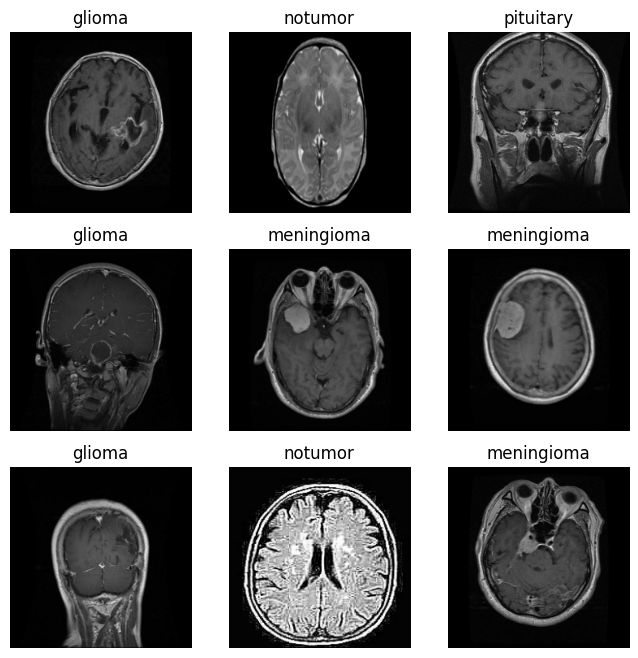

In [24]:
# ---- smoke-test ----
from src.utils import set_global_determinism
set_global_determinism(42)

from src.datamodule import DataModule
import tensorflow as tf
import matplotlib.pyplot as plt
import pathlib

SRC_DIR = pathlib.Path("/content/drive/MyDrive/Final_2025_Comp/SP/src")
dm = DataModule(cfg_path=str(SRC_DIR / "config.yaml"))

def n_items(ds):  # safer than len(ds)
    return tf.data.experimental.cardinality(ds).numpy()

print("Classes:", dm.class_names)
print("Batches — train:", n_items(dm.train_ds),
      "val:", n_items(dm.val_ds), "test:", n_items(dm.test_ds))

# Peek at a few images
x, y = next(iter(dm.train_ds))
plt.figure(figsize=(8,8))
for i in range(9):
    ax = plt.subplot(3,3,i+1)
    plt.imshow(x[i].numpy().astype("uint8"))
    lbl = dm.class_names[y[i].numpy().argmax()]  # works because label_mode='categorical'
    plt.title(lbl)
    plt.axis("off")
plt.show()

## Transfer learning

Each ImageNet backbone is followed by global average pooling, a 512-unit dense layer, dropout and a four-class softmax. Training starts with a frozen backbone, followed by fine-tuning.


In [26]:

%%writefile /content/drive/MyDrive/Final_2025_Comp/SP/src/model_factory.py
import tensorflow as tf
from typing import Tuple, Dict, Callable

# --------------------------------------------------------------------
# 1)  Map backbone name  ->  (constructor, preprocess_input)
# --------------------------------------------------------------------
BACKBONES: Dict[str, Tuple[Callable, Callable]] = dict(
    xception       = (
        tf.keras.applications.Xception,
        tf.keras.applications.xception.preprocess_input
    ),
    vgg16          = (
        tf.keras.applications.VGG16,
        tf.keras.applications.vgg16.preprocess_input
    ),
    efficientnetb0 = (
        tf.keras.applications.EfficientNetB0,
        tf.keras.applications.efficientnet.preprocess_input
    ),
)

# --------------------------------------------------------------------
# 2)  Build the transfer-learning model
# --------------------------------------------------------------------
def build_model(backbone: str,
                img_size: Tuple[int, int],
                num_classes: int,
                base_trainable: bool = False) -> tf.keras.Model:
    """
    backbone: one of 'xception', 'vgg16', 'efficientnetb0'
    img_size: (H, W)
    num_classes: number of output classes
    base_trainable: if True, leave the conv base unfrozen (for fine-tune phase)
    """
    if backbone not in BACKBONES:
        raise ValueError(f"Unknown backbone {backbone!r}. "
                         f"Choose from {list(BACKBONES)}")

    Base, preprocess = BACKBONES[backbone]

    inputs  = tf.keras.Input(shape=(*img_size, 3))
    x       = preprocess(inputs)
    base    = Base(include_top=False,
                   weights="imagenet",
                   input_tensor=x)
    base.trainable = base_trainable                 # freeze or unfreeze

    x = tf.keras.layers.GlobalAveragePooling2D()(base.output)
    x = tf.keras.layers.Dense(512, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    return tf.keras.Model(inputs, outputs,
                          name=f"{backbone}_transfer")
# --------------------------------------------------------------------
# 3)  Standard compile helper
# --------------------------------------------------------------------
def compile_model(model: tf.keras.Model, lr: float = 1e-3) -> None:
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="categorical_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="prec"),
            tf.keras.metrics.Recall(name="rec"),
        ],
    )
print("✓  model_factory.py written")

Overwriting /content/drive/MyDrive/Final_2025_Comp/SP/src/model_factory.py


In [27]:
import sys, pathlib, importlib
PROJECT_ROOT = pathlib.Path("/content/drive/MyDrive/Final_2025_Comp/SP")
if PROJECT_ROOT.as_posix() not in sys.path:
    sys.path.append(PROJECT_ROOT.as_posix())

from src.utils import set_global_determinism
from src.datamodule import DataModule
from src.model_factory import build_model, compile_model

set_global_determinism(42)
dm = DataModule(str(PROJECT_ROOT / "src/config.yaml"))

# build an Xception model frozen (head-training phase)
model = build_model("xception", tuple(dm.cfg["img_size"]), len(dm.class_names))
compile_model(model, lr=dm.cfg["lr_head"])
model.summary(line_length=100)

Found 5349 files belonging to 4 classes.
Found 945 files belonging to 4 classes.
Found 859 files belonging to 4 classes.


Model: "xception_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                ┃ Output Shape            ┃        Param # ┃ Connected to            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)  │ (None, 224, 224, 3)     │              0 │ -                       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ true_divide_1 (TrueDivide)  │ (None, 224, 224, 3)     │              0 │ input_layer_1[0][0]     │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ subtract_1 (Subtract)       │ (None, 224, 224, 3)     │              0 │ true_divide_1[0][0]     │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block1_conv1 (Conv2D)       │ (None, 111, 111, 32)    │            864 │ subtract_1[0][0]        │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block1_conv1_bn             │ (None, 111, 111, 32)    │            128 │ block1_conv1[0][0]      │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block1_conv1_act            │ (None, 111, 111, 32)    │              0 │ block1_conv1_bn[0][0]   │
│ (Activation)                │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block1_conv2 (Conv2D)       │ (None, 109, 109, 64)    │         18,432 │ block1_conv1_act[0][0]  │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block1_conv2_bn             │ (None, 109, 109, 64)    │            256 │ block1_conv2[0][0]      │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block1_conv2_act            │ (None, 109, 109, 64)    │              0 │ block1_conv2_bn[0][0]   │
│ (Activation)                │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block2_sepconv1             │ (None, 109, 109, 128)   │          8,768 │ block1_conv2_act[0][0]  │
│ (SeparableConv2D)           │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block2_sepconv1_bn          │ (None, 109, 109, 128)   │            512 │ block2_sepconv1[0][0]   │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block2_sepconv2_act         │ (None, 109, 109, 128)   │              0 │ block2_sepconv1_bn[0][… │
│ (Activation)                │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block2_sepconv2             │ (None, 109, 109, 128)   │         17,536 │ block2_sepconv2_act[0]… │
│ (SeparableConv2D)           │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block2_sepconv2_bn          │ (None, 109, 109, 128)   │            512 │ block2_sepconv2[0][0]   │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────

 Total params: 21,912,620 (83.59 MB)

 Trainable params: 1,051,140 (4.01 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

## Model inspection

The saved model summary shows the backbone and classifier head used in the experiment.


## Ensemble

Average the three models’ class probabilities, then select the largest probability.


The following cells train each backbone. These are the submitted experiments, with historical saved outputs.


In [41]:
%%writefile /content/drive/MyDrive/Final_2025_Comp/SP/src/train.py
import sys, pathlib
PROJECT_ROOT = pathlib.Path(__file__).resolve().parents[1]
if PROJECT_ROOT.as_posix() not in sys.path:
    sys.path.insert(0, PROJECT_ROOT.as_posix())

import argparse, yaml
from pathlib import Path

import tensorflow as tf  # keep this at top-level

from src.utils import set_global_determinism
from src.datamodule import DataModule
from src.model_factory import build_model, compile_model


def unfreeze_backbone_layers(model, n_last: int):
    """Unfreeze last n_last layers of the conv backbone (before GAP)."""
    # Find GAP layer index (start of dense head)
    gap_idx = None
    for i, lyr in enumerate(model.layers):
        if isinstance(lyr, tf.keras.layers.GlobalAveragePooling2D):
            gap_idx = i
            break
    if gap_idx is None:
        raise RuntimeError("Could not locate GlobalAveragePooling2D layer.")

    backbone_layers = model.layers[:gap_idx]  # everything before GAP
    # Unfreeze last n_last conv layers (skip BatchNorms)
    for lyr in backbone_layers[-n_last:]:
        if not isinstance(lyr, tf.keras.layers.BatchNormalization):
            lyr.trainable = True
    # Keep BN frozen (often stabilises fine-tuning)
    for lyr in backbone_layers:
        if isinstance(lyr, tf.keras.layers.BatchNormalization):
            lyr.trainable = False


def main(cfg_path: str, backbone: str):
    # ---------- load config ----------
    with open(cfg_path) as f:
        cfg = yaml.safe_load(f)

    set_global_determinism(cfg["seed"])
    dm = DataModule(cfg_path)
    img_size     = tuple(cfg["img_size"])
    num_classes  = len(dm.class_names)

    model_dir = Path(cfg["model_dir"])
    model_dir.mkdir(parents=True, exist_ok=True)

    # ---------- Phase 1 : head training ----------
    model = build_model(backbone, img_size, num_classes, base_trainable=False)
    compile_model(model, lr=cfg["lr_head"])

    ckpt_head = model_dir / f"{backbone}_head.keras"
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=cfg["early_stop_patience"],
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(ckpt_head),
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        ),
        tf.keras.callbacks.TensorBoard(
            log_dir=str(Path(cfg["log_dir"]) / f"{backbone}_head")
        )
    ]

    model.fit(
        dm.train_ds,
        validation_data=dm.val_ds,
        epochs=cfg["epochs_head"],
        callbacks=callbacks,
        verbose=1
    )

    # ---------- Phase 2 : fine-tune ----------
    unfreeze_backbone_layers(model, cfg["unfreeze_layers"])
    compile_model(model, lr=cfg["lr_finetune"])

    ckpt_ft = model_dir / f"{backbone}_finetune.keras"
    callbacks[1].filepath = str(ckpt_ft)
    callbacks[2].log_dir  = str(Path(cfg["log_dir"]) / f"{backbone}_finetune")

    model.fit(
        dm.train_ds,
        validation_data=dm.val_ds,
        epochs=cfg["epochs_finetune"],
        callbacks=callbacks,
        verbose=1
    )

    print(f"✅ Finished training {backbone}. Head → {ckpt_head.name}, fine-tuned → {ckpt_ft.name}")


if __name__ == "__main__":
    ap = argparse.ArgumentParser()
    ap.add_argument("--cfg",      default="src/config.yaml")
    ap.add_argument("--backbone", choices=["xception","vgg16","efficientnetb0"],
                    default="xception")
    args = ap.parse_args()
    main(args.cfg, args.backbone)

Overwriting /content/drive/MyDrive/Final_2025_Comp/SP/src/train.py


## Train Xception


In [42]:
%cd /content/drive/MyDrive/Final_2025_Comp/SP
!python -m src.train --cfg src/config.yaml --backbone xception

/content/drive/MyDrive/Final_2025_Comp/SP
2025-07-27 15:57:47.326068: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753631867.345678   54792 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753631867.351556   54792 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
✓ utils.py written.
✓  model_factory.py written
Found 5349 files belonging to 4 classes.
2025-07-27 15:57:52.923846: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1753631872.924030   54792 gpu_device.cc:2022] Created device /job:localhost/re

## Train VGG16


In [44]:
%cd /content/drive/MyDrive/Final_2025_Comp/SP
!python -m src.train --cfg src/config.yaml --backbone vgg16

/content/drive/MyDrive/Final_2025_Comp/SP
2025-07-27 16:03:11.090087: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753632191.111047   57827 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753632191.117700   57827 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
✓ utils.py written.
✓  model_factory.py written
Found 5349 files belonging to 4 classes.
2025-07-27 16:03:16.631453: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1753632196.631597   57827 gpu_device.cc:2022] Created device /job:localhost/re

## Train EfficientNetB0


In [45]:
%cd /content/drive/MyDrive/Final_2025_Comp/SP
!python -m src.train --cfg src/config.yaml --backbone efficientnetb0

/content/drive/MyDrive/Final_2025_Comp/SP
2025-07-27 16:07:48.457169: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753632468.476978   60571 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753632468.482963   60571 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
✓ utils.py written.
✓  model_factory.py written
Found 5349 files belonging to 4 classes.
2025-07-27 16:07:54.001319: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1753632474.001465   60571 gpu_device.cc:2022] Created device /job:localhost/re

In [34]:
%load_ext tensorboard
%tensorboard --logdir "/content/drive/MyDrive/Final_2025_Comp/SP/models/logs"

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 47681), started 0:00:10 ago. (Use '!kill 47681' to kill it.)

<IPython.core.display.Javascript object>

## Checkpoints

Evaluation loads the fine-tuned checkpoints. Weights and the image dataset are not included in this repository.


## Test evaluation

Compute accuracy, macro-F1, confusion matrices, ROC curves and 15-bin expected calibration error. This code evaluates averaged probabilities without a fitted temperature-scaling step.


In [46]:
# ---- Test-set evaluation & ensemble ----
from pathlib import Path
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
)

from src.utils import set_global_determinism
from src.datamodule import DataModule

set_global_determinism(42)

PROJECT_ROOT = Path("/content/drive/MyDrive/Final_2025_Comp/SP")
SRC_DIR   = PROJECT_ROOT / "src"
MODEL_DIR = PROJECT_ROOT / "models"
PLOT_DIR  = PROJECT_ROOT / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

dm = DataModule(str(SRC_DIR / "config.yaml"))
class_names = dm.class_names
n_classes   = len(class_names)

# -------- helper functions --------
def preds_and_labels(model, dataset):
    y_prob, y_true = [], []
    for xb, yb in dataset:
        y_prob.append(model.predict(xb, verbose=0))
        y_true.append(yb.numpy())
    y_prob   = np.concatenate(y_prob)
    y_true_oh = np.concatenate(y_true)
    y_true   = y_true_oh.argmax(axis=1)
    y_pred   = y_prob.argmax(axis=1)
    return y_true, y_true_oh, y_prob, y_pred

def expected_calibration_error(y_true, y_prob, n_bins=15):
    conf = y_prob.max(axis=1)
    pred = y_prob.argmax(axis=1)
    correct = (pred == y_true).astype(float)

    bins = np.linspace(0,1,n_bins+1)
    ece = 0.0
    bin_acc, bin_conf = [], []
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        idx = (conf > lo) & (conf <= hi)
        if idx.any():
            bc = conf[idx].mean()
            ba = correct[idx].mean()
            ece += (idx.sum()/len(y_true)) * abs(ba - bc)
            bin_conf.append(bc); bin_acc.append(ba)
        else:
            bin_conf.append(np.nan); bin_acc.append(np.nan)
    return ece, bins, bin_acc, bin_conf

# -------- load models --------
models = {}
for name in ["xception", "vgg16", "efficientnetb0"]:
    path = MODEL_DIR / f"{name}_finetune.keras"
    if path.exists():
        models[name] = tf.keras.models.load_model(path)
        print("Loaded", path.name)

results = {}
for name, m in models.items():
    yt, yt_oh, yp, yhat = preds_and_labels(m, dm.test_ds)
    acc  = accuracy_score(yt, yhat)
    f1m  = f1_score(yt, yhat, average="macro")
    rep  = classification_report(yt, yhat, target_names=class_names, output_dict=True)
    results[name] = dict(y_true=yt, y_true_oh=yt_oh, y_prob=yp, y_pred=yhat,
                         acc=acc, f1_macro=f1m, report=rep)

# -------- ensemble (mean probs) --------
if len(results) > 1:
    probs = np.mean([r["y_prob"] for r in results.values()], axis=0)
    yt = next(iter(results.values()))["y_true"]
    yhat = probs.argmax(axis=1)
    acc  = accuracy_score(yt, yhat)
    f1m  = f1_score(yt, yhat, average="macro")
    results["ensemble"] = dict(y_true=yt, y_prob=probs, y_pred=yhat,
                               acc=acc, f1_macro=f1m)
    print(f"Ensemble  acc={acc:.4f}, macro-F1={f1m:.4f}")

# -------- choose which to plot (ensemble if available) --------
key = "ensemble" if "ensemble" in results else max(results, key=lambda k: results[k]["f1_macro"])
yt   = results[key]["y_true"]
yhat = results[key]["y_pred"]
yprob= results[key]["y_prob"]

# Confusion matrix
cm = confusion_matrix(yt, yhat)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(xticks_rotation=45)
plt.tight_layout()
plt.savefig(PLOT_DIR / f"cm_test_{key}.png", dpi=300)
plt.close()

# ROC curves
yt_oh = tf.keras.utils.to_categorical(yt, num_classes=n_classes)
plt.figure()
for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(yt_oh[:, i], yprob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.3f})")
plt.plot([0,1],[0,1],'--', color='grey')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title(f"ROC — {key} (test)")
plt.legend(); plt.tight_layout()
plt.savefig(PLOT_DIR / f"roc_test_{key}.png", dpi=300); plt.close()

# Reliability / ECE
ece, bins, b_acc, b_conf = expected_calibration_error(yt, yprob, n_bins=15)
centres = 0.5*(bins[1:]+bins[:-1])
mask = ~np.isnan(b_acc)
plt.bar(centres[mask], np.array(b_acc)[mask], width=1/len(centres), alpha=0.5, label="Accuracy")
plt.plot(centres, b_conf, 'o-', label="Confidence")
plt.plot([0,1],[0,1],'--', color='grey')
plt.xlabel("Confidence"); plt.ylabel("Accuracy")
plt.title(f"Reliability diagram — {key} (test)\nECE={ece:.3f}")
plt.legend(); plt.tight_layout()
plt.savefig(PLOT_DIR / f"reliability_test_{key}.png", dpi=300); plt.close()

# Table of metrics
rows = []
for name, r in results.items():
    rows.append({"model": name, "accuracy": r["acc"], "f1_macro": r["f1_macro"]})
metrics_df = pd.DataFrame(rows).sort_values("f1_macro", ascending=False)
metrics_df

Found 5349 files belonging to 4 classes.
Found 945 files belonging to 4 classes.
Found 859 files belonging to 4 classes.
Loaded xception_finetune.keras
Loaded vgg16_finetune.keras
Loaded efficientnetb0_finetune.keras
Ensemble  acc=0.9756, macro-F1=0.9749


,model,accuracy,f1_macro
3,ensemble,0.975553,0.974885
2,efficientnetb0,0.966240,0.965157
0,xception,0.960419,0.959525
1,vgg16,0.960419,0.959517


from matplotlib import pyplot as plt
metrics_df['accuracy'].plot(kind='hist', bins=20, title='accuracy')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
metrics_df['f1_macro'].plot(kind='hist', bins=20, title='f1_macro')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
metrics_df.groupby('model').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

...

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(metrics_df['model'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(metrics_df, x='accuracy', y='model', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(metrics_df['model'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(metrics_df, x='f1_macro', y='model', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

ERROR:root:Did not find quickchart key chart-3fd18f77-0898-4b5b-95b2-cc7f1ac20fb5 in chart cache
ERROR:root:Did not find quickchart key chart-3fd18f77-0898-4b5b-95b2-cc7f1ac20fb5 in chart cache
ERROR:root:Did not find quickchart key chart-3fd18f77-0898-4b5b-95b2-cc7f1ac20fb5 in chart cache
ERROR:root:Did not find quickchart key chart-a7301442-92bf-4cdf-8f6d-c8cdbb49970f in chart cache
ERROR:root:Did not find quickchart key chart-a7301442-92bf-4cdf-8f6d-c8cdbb49970f in chart cache
ERROR:root:Did not find quickchart key chart-69708f0b-1909-442a-9057-28aa26ffaac0 in chart cache
ERROR:root:Did not find quickchart key chart-27b55fee-47b7-4df6-aafe-41e36fecbf1c in chart cache
ERROR:root:Did not find quickchart key chart-9ddbedcb-c5b8-423f-8084-23b18b998101 in chart cache
ERROR:root:Did not find quickchart key chart-27b55fee-47b7-4df6-aafe-41e36fecbf1c in chart cache


In [53]:
from sklearn.metrics import classification_report

key = "ensemble" if "ensemble" in results else max(results, key=lambda k: results[k]["f1_macro"])
yt   = results[key]["y_true"]
yhat = results[key]["y_pred"]

# Add report if missing
if "report" not in results[key]:
    results[key]["report"] = classification_report(
        yt, yhat, target_names=class_names, output_dict=True
    )

# Now you can save
metrics_df.to_csv(PLOT_DIR / "test_metrics.csv", index=False)

per_class_df = pd.DataFrame(results[key]["report"]).T
per_class_df.to_csv(PLOT_DIR / "per_class_report.csv")
per_class_df.head()

,precision,recall,f1-score,support
glioma,0.989130,0.933333,0.960422,195.000000
meningioma,0.937500,0.985915,0.961098,213.000000
notumor,0.987500,0.987500,0.987500,240.000000
pituitary,0.990521,0.990521,0.990521,211.000000
accuracy,0.975553,0.975553,0.975553,0.975553


In [54]:
def safe_report(res, names):
    if "report" in res:
        return res["report"]
    return classification_report(res["y_true"], res["y_pred"],
                                 target_names=names, output_dict=True)

## Confidence evaluation

The saved ensemble ECE is 0.01528. This measures binned confidence error on this test split. The submitted narrative claimed temperature scaling, but no fitting step is present. Do not describe these outputs as temperature-calibrated.


In [62]:
print("ECE (chosen model):", ece)

ECE (chosen model): 0.015280134256005383


In [66]:
ece_dict = {}
for name, r in results.items():
    ece_dict[name] = expected_calibration_error(r["y_true"], r["y_prob"], n_bins=15)[0]

# Add calibrated ensemble only if available
if "probs_cal" in globals():
    ece_after, *_ = expected_calibration_error(yt, probs_cal, n_bins=15)
    ece_dict["ensemble_tempcal"] = ece_after

ece_df = pd.DataFrame([{"model": k, "ECE": v} for k, v in ece_dict.items()])\
         .sort_values("ECE")
display(ece_df)

,model,ECE
1,vgg16,0.008546
3,ensemble,0.015280
2,efficientnetb0,0.015439
0,xception,0.020519


## Grad-CAM

Heatmaps provide a qualitative way to inspect model responses. They do not verify tumour localisation or clinical validity.


In [55]:
%%writefile /content/drive/MyDrive/Final_2025_Comp/SP/src/gradcam.py
"""
Grad-CAM utilities with automatic last-conv-layer detection.
Usage example (in a notebook):

    from pathlib import Path
    import tensorflow as tf
    from src.datamodule import DataModule
    from src.gradcam import save_gradcam_grid

    PROJECT_ROOT = Path("/content/drive/MyDrive/Final_2025_Comp/SP")
    dm = DataModule(str(PROJECT_ROOT / "src/config.yaml"))

    model = tf.keras.models.load_model(PROJECT_ROOT / "models" / "efficientnetb0_finetune.keras")
    save_gradcam_grid(model, dm, model_name="efficientnetb0_finetune", num_samples=8)

"""

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

# --------------------------------------------------------------
# Helpers
# --------------------------------------------------------------
def find_last_conv_layer(model):
    """
    Walk backwards through layers and return the name of the last 2D conv-like layer.
    Handles Conv2D, SeparableConv2D, DepthwiseConv2D.
    Raises if none found.
    """
    conv_types = (tf.keras.layers.Conv2D,
                  tf.keras.layers.SeparableConv2D,
                  tf.keras.layers.DepthwiseConv2D)
    for layer in reversed(model.layers):
        if isinstance(layer, conv_types):
            return layer.name
    raise RuntimeError("No 2D convolutional layer found in the model.")


def make_gradcam_heatmap(img_array, model, last_conv_layer_name=None, pred_index=None):
    """
    Generate a Grad-CAM heatmap for a single (1, H, W, 3) image batch.
    If last_conv_layer_name is None, detect it automatically.
    """
    if last_conv_layer_name is None:
        last_conv_layer_name = find_last_conv_layer(model)

    # Model mapping input -> (last conv outputs, predictions)
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # Gradients of the top predicted class wrt conv layer
    grads = tape.gradient(class_channel, conv_out)

    # Global average pooling the gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_out = conv_out[0]  # HxWxC
    heatmap = tf.tensordot(conv_out, pooled_grads, axes=[2, 0])

    # ReLU & normalise 0-1
    heatmap = tf.maximum(heatmap, 0)
    denom = tf.reduce_max(heatmap)
    heatmap = heatmap / (denom + 1e-8)

    return heatmap.numpy()


def overlay_heatmap_on_image(heatmap, img_uint8, alpha=0.4):
    """
    Resize heatmap to image size, colour it, and overlay onto the original image.
    img_uint8 expected shape (H, W, 3) in [0,255].
    """
    h, w = img_uint8.shape[:2]
    heatmap_resized = cv2.resize(heatmap, (w, h))
    heatmap_uint8   = np.uint8(255 * heatmap_resized)
    heatmap_color   = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(heatmap_color, alpha, img_uint8, 1 - alpha, 0)
    return overlay


# --------------------------------------------------------------
# Main public API
# --------------------------------------------------------------
def save_gradcam_grid(model, datamodule, model_name, num_samples=8, save_dir=None):
    """
    Create & save a grid of Grad-CAM overlays for a few test images.

    Parameters
    ----------
    model : tf.keras.Model
    datamodule : DataModule (needs .test_ds and .class_names)
    model_name : str  -> used in figure title & filename
    num_samples : int -> number of images to visualise (max drawn from first batch)
    save_dir : pathlib.Path or str or None
        Directory to save PNG. Defaults to PROJECT_ROOT/plots if None.

    Returns
    -------
    Path to saved PNG.
    """
    if save_dir is None:
        # assume same structure as elsewhere in project
        save_dir = Path("/content/drive/MyDrive/Final_2025_Comp/SP/plots")
    else:
        save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    # Try to find last conv automatically once
    try:
        last_conv = find_last_conv_layer(model)
    except RuntimeError as e:
        print("Grad-CAM skipped:", e)
        return None

    # Grab one batch from test
    test_iter = iter(datamodule.test_ds)
    x_batch, y_batch = next(test_iter)

    max_show = min(num_samples, x_batch.shape[0])
    h, w = model.input_shape[1:3]

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()

    for i in range(max_show):
        img = x_batch[i:i+1]                          # (1,H,W,3) float32 0-255
        true_label = int(tf.argmax(y_batch[i]).numpy())

        # Prediction
        preds = model.predict(img, verbose=0)
        pred_label = int(np.argmax(preds[0]))
        pred_conf  = float(preds[0][pred_label])

        # Heatmap
        try:
            heatmap = make_gradcam_heatmap(img, model, last_conv_layer_name=last_conv)
            # Ensure image is uint8
            img_uint8 = img[0].numpy().astype(np.uint8)
            overlay   = overlay_heatmap_on_image(heatmap, img_uint8, alpha=0.4)

            axes[i].imshow(overlay)
            axes[i].set_title(
                f"True: {datamodule.class_names[true_label]}\n"
                f"Pred: {datamodule.class_names[pred_label]} ({pred_conf:.2%})",
                color=("green" if true_label == pred_label else "red")
            )
            axes[i].axis("off")

        except Exception as ex:
            axes[i].imshow(img[0].numpy().astype(np.uint8))
            axes[i].set_title(f"Grad-CAM failed\n{ex}", color="red", fontsize=8)
            axes[i].axis("off")
            print(f"Grad-CAM failed for sample {i}: {ex}")

    # Fill unused axes (if any)
    for j in range(max_show, len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"Grad-CAM — {model_name}", fontsize=16)
    plt.tight_layout()
    out_path = save_dir / f"{model_name}_gradcam.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved Grad-CAM grid to {out_path}")
    return out_path

Overwriting /content/drive/MyDrive/Final_2025_Comp/SP/src/gradcam.py


In [67]:

# ece_df = pd.DataFrame([{"model": k, "ECE": v} for k, v in ece_dict.items()])

metrics_df = metrics_df.merge(ece_df, on="model", how="left")
metrics_df.to_csv(PLOT_DIR / "test_metrics_with_calibration.csv", index=False)
display(metrics_df)

,model,acc,f1_macro,ECE
0,ensemble,0.975553,0.974885,0.015280
1,efficientnetb0,0.966240,0.965157,0.015439
2,xception,0.960419,0.959525,0.020519
3,vgg16,0.960419,0.959517,0.008546


## Reproducing the work

This notebook retains the original Colab setup. Use the repository README for current local scripts. No fresh training run was performed during the portfolio restoration.


## Results

The ensemble achieved 97.56% accuracy and 97.49% macro-F1. EfficientNetB0, the strongest individual model in the saved table, achieved 96.62% accuracy. These comparisons share one test split and do not establish superiority over published studies.


## Interpreting heatmaps

Review the saved examples as qualitative diagnostics only.


Grad-CAM examples cannot rule out shortcuts or replace expert annotations and quantitative localisation evaluation.


Found 5349 files belonging to 4 classes.
Found 945 files belonging to 4 classes.
Found 859 files belonging to 4 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


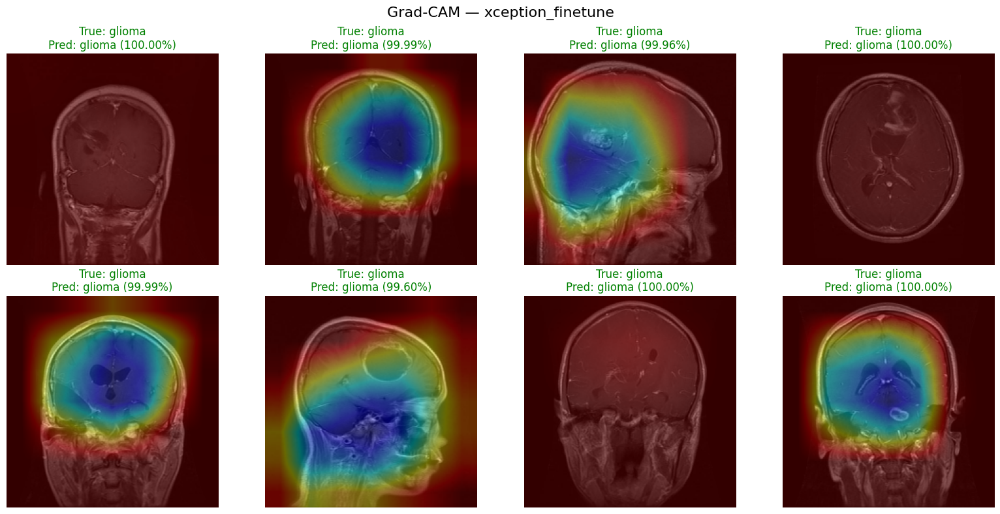

Saved Grad-CAM grid to /content/drive/MyDrive/Final_2025_Comp/SP/plots/xception_finetune_gradcam.png


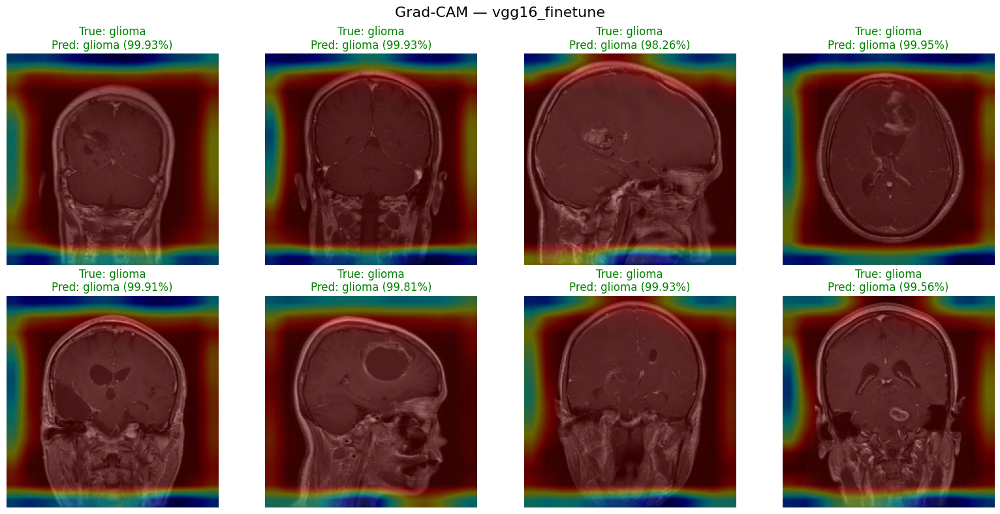

Saved Grad-CAM grid to /content/drive/MyDrive/Final_2025_Comp/SP/plots/vgg16_finetune_gradcam.png


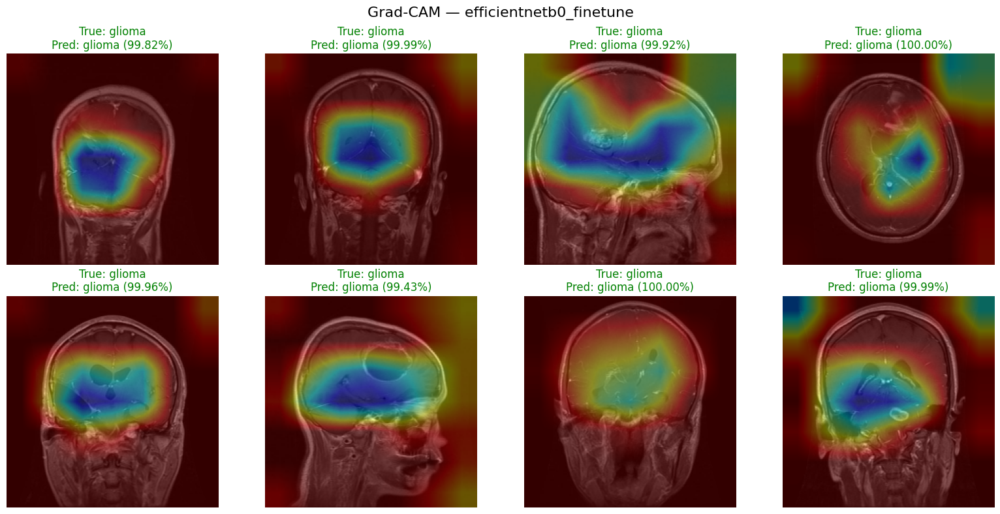

Saved Grad-CAM grid to /content/drive/MyDrive/Final_2025_Comp/SP/plots/efficientnetb0_finetune_gradcam.png


In [56]:
from pathlib import Path
import tensorflow as tf
from src.datamodule import DataModule
from src.gradcam import save_gradcam_grid

PROJECT_ROOT = Path("/content/drive/MyDrive/Final_2025_Comp/SP")
dm = DataModule(str(PROJECT_ROOT/"src/config.yaml"))

for name in ["xception","vgg16","efficientnetb0"]:
    model = tf.keras.models.load_model(PROJECT_ROOT/"models"/f"{name}_finetune.keras")
    save_gradcam_grid(model, dm, f"{name}_finetune", num_samples=8)

## Evaluation lessons

The original notes describe an earlier validation-as-test run. The final saved evaluation explicitly loads 859 test images. The maintained loader now rejects missing split directories rather than substituting validation data.


## Limitations and next steps


Patient-level splitting, documented dataset provenance and independent evaluation would strengthen this project. Temperature scaling would require a separate implementation fitted on validation data and a before/after evaluation.


## Export saved results

The following cell exports metrics and a summary. It has not been rerun during restoration.


In [61]:
# ============================================
# FINAL CELL — Summary + Export Bundle
# ============================================
from pathlib import Path
import pandas as pd, numpy as np, json, zipfile, os
from datetime import datetime

# -------- Paths --------
PROJECT_ROOT = Path("/content/drive/MyDrive/Final_2025_Comp/SP")
PLOT_DIR     = PROJECT_ROOT / "plots"
MODEL_DIR    = PROJECT_ROOT / "models"
SRC_DIR      = PROJECT_ROOT / "src"

PLOT_DIR.mkdir(parents=True, exist_ok=True)

# -------- Load / normalise metrics_df --------
metrics_csv = PLOT_DIR / "test_metrics_with_calibration.csv"
if 'metrics_df' not in globals():
    if metrics_csv.exists():
        metrics_df = pd.read_csv(metrics_csv)
    else:
        raise FileNotFoundError("metrics_df not in memory and test_metrics_with_calibration.csv not found.")

# Normalise column names just in case
rename_map = {}
if "accuracy" in metrics_df.columns and "acc" not in metrics_df.columns:
    rename_map["accuracy"] = "acc"
if "macro_F1" in metrics_df.columns and "f1_macro" not in metrics_df.columns:
    rename_map["macro_F1"] = "f1_macro"
metrics_df = metrics_df.rename(columns=rename_map)

# Pick best variant robustly
candidates = ["ensemble_tempcal", "ensemble", "ensemble_uncal", "ensemble_stack"]
BEST_VARIANT = next((m for m in candidates if m in metrics_df["model"].values),
                    metrics_df.sort_values("f1_macro", ascending=False).iloc[0]["model"])

best_row = metrics_df.set_index("model").loc[BEST_VARIANT]

acc_val = float(best_row.get("acc", np.nan))
f1_val  = float(best_row.get("f1_macro", np.nan))
ece_val = float(best_row.get("ECE", np.nan))

# Get test size if 'results' exists
if 'results' in globals() and BEST_VARIANT in results:
    n_test_images = len(results[BEST_VARIANT]["y_true"])
elif 'results' in globals():
    # fall back to any entry
    n_test_images = len(next(iter(results.values()))["y_true"])
else:
    n_test_images = "NA"

# -------- Build summary dict --------
summary = {
    "timestamp_utc": datetime.utcnow().isoformat() + "Z",
    "best_variant": BEST_VARIANT,
    "accuracy": acc_val,
    "macro_F1": f1_val,
    "ECE": ece_val,
    "n_test_images": n_test_images,
    "classes": class_names if 'class_names' in globals() else "NA",
    "notes": "Metrics computed on held-out stratified test set (12%). Uncalibrated mean-probability ensemble; no temperature fitting step is present."
}

# -------- Save artefacts --------
summary_path = PROJECT_ROOT / "final_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

final_metrics_csv = PLOT_DIR / "test_metrics_final.csv"
metrics_df.to_csv(final_metrics_csv, index=False)

print("✔ Summary JSON:", summary_path)
print("✔ Metrics CSV :", final_metrics_csv)

# -------- Optional ZIP bundle --------
INCLUDE_MODELS = False  # flip to True if you *must* ship weights (huge!)
zip_path = PROJECT_ROOT / "submission_bundle.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    # essentials
    for p in [
        PROJECT_ROOT / "splits.csv",
        summary_path,
        final_metrics_csv,
        PLOT_DIR / f"cm_test_{BEST_VARIANT}.png",
        PLOT_DIR / f"roc_test_{BEST_VARIANT}.png",
        PLOT_DIR / f"reliability_test_{BEST_VARIANT}.png",
    ]:
        if p.exists():
            z.write(p, p.relative_to(PROJECT_ROOT))

    # Grad-CAMs
    for p in PLOT_DIR.glob("*gradcam*.png"):
        z.write(p, p.relative_to(PROJECT_ROOT))

    # source code
    for root, _, files in os.walk(SRC_DIR):
        for fn in files:
            fp = Path(root) / fn
            z.write(fp, fp.relative_to(PROJECT_ROOT))

    # models (optional)
    if INCLUDE_MODELS:
        for p in MODEL_DIR.glob("*.keras"):
            z.write(p, p.relative_to(PROJECT_ROOT))

print("✔ Bundle ZIP  :", zip_path)

# -------- Pretty print TL;DR --------
print("\nTL;DR:")
print(f"  Best variant  : {BEST_VARIANT}")
print(f"  Accuracy       : {acc_val:.4f}")
print(f"  Macro-F1       : {f1_val:.4f}")
if not np.isnan(ece_val):
    print(f"  ECE            : {ece_val:.4f}")

# If you're in Colab/Jupyter and want to see the table:
try:
    from IPython.display import display
    display(metrics_df)
except Exception:
    print("\nMetrics table:")
    print(metrics_df)

✔ Summary JSON: /content/drive/MyDrive/Final_2025_Comp/SP/final_summary.json
✔ Metrics CSV : /content/drive/MyDrive/Final_2025_Comp/SP/plots/test_metrics_final.csv
✔ Bundle ZIP  : /content/drive/MyDrive/Final_2025_Comp/SP/submission_bundle.zip

TL;DR:
  Best variant  : ensemble
  Accuracy       : 0.9756
  Macro-F1       : 0.9749


,model,acc,f1_macro
3,ensemble,0.975553,0.974885
2,efficientnetb0,0.966240,0.965157
0,xception,0.960419,0.959525
1,vgg16,0.960419,0.959517


## Future work

Recover full dataset provenance, verify patient grouping and duplicate content, and evaluate on an independent dataset before making generalisation claims.


## Final results take precedence

Use test_metrics_final.csv for the 859-image test results. Earlier validation-based figures are not comparable and are not the final results.


In [1]:
!pip freeze > requirements.txt

In [ ]:
!cp requirements.txt /content/drive/MyDrive/Final_2025_Comp/SP/

## Portfolio documentation

See README.md for installation and current commands.


See the repository file tree in README.md. The original notebook paths are retained for provenance.


## Dataset provenance

The submitted notes cite the tombackert Brain Tumor MRI Data collection on Kaggle. The exact downloaded snapshot and its relationship to the source collections are not independently verified. The previous repository link to a different dataset was removed.


## Research practice

Use explicit evaluation splits and distinguish measured confidence error from calibration fitting. No clinical validation or formal compliance certification is claimed.


## References

The historical report contains the submitted references. The portfolio does not independently verify every reference or reproduce its clinical claims.
